# Given implementation

In [1]:
# # !pip install diffusers
# from diffusers import DiffusionPipeline

# model_id = "google/ncsnpp-celebahq-256"

# # load model and scheduler
# sde_ve = DiffusionPipeline.from_pretrained(model_id)

# # run pipeline in inference (sample random noise and denoise)
# image = sde_ve()["sample"]


# # save image
# image[0].save("sde_ve_generated_image.png")

# Reverse Process Test

In [2]:
import sys, importlib, os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils
from typing import Tuple
import yaml
from pathlib import Path
from datetime import datetime
import numpy as np

# Parameters to set

In [3]:
# Set the following parameters
sde_type = "vp"
num_steps = 1000
batch_size = 1

cfg = {
    "sde_type": sde_type,
    "N": num_steps
}

In [4]:
# Importing project packages
cwd = Path(os.getcwd())
root_dir = cwd.parent

utils_dir = root_dir.joinpath('src','utils')
weights_dir = root_dir.joinpath('checkpoints','weights')
model_dir = root_dir.joinpath('src','model')
yaml_file_path = root_dir.joinpath('experiments','base_config.yaml')


# Making packages importable
sys.path.append(str(root_dir))

In [5]:
from src.utils import WIP_SDE, WIP_processes
from src.models import unet_model, components
from src.models import unet_model


importlib.reload(WIP_SDE)
importlib.reload(WIP_processes)
importlib.reload(components)
importlib.reload(unet_model)

UNet = unet_model.UNet
from src.utils.WIP_SDE import VESDE, SubVPSDE
from src.utils.WIP_processes import Diffusion_Processes
from src.models.components import SinusoidalPositionEmbeddings # Required by unet_model
#from src.models.unet_model import UNet

In [6]:
diffusion = Diffusion_Processes(cfg)

In [7]:
import torch
from diffusers import UNet2DModel

# 1. Load Model
if cfg['sde_type'] == 've':
    model_id = "google/ncsnpp-celebahq-256"
    image_size = 256
else:
    model_id = "google/ddpm-cifar10-32"
    image_size = 64

model = UNet2DModel.from_pretrained(model_id)
device = "cpu"
model.to(device)
model.eval()

UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(12

In [8]:
# 2. Define the Wrapper (Fixes the TypeError)
def model_fn(x, t):
    # Diffusers expects t to be shape (B,) or a scalar, usually handles it fine.
    with torch.no_grad():
        out = model(x, t)
    
    # Extract the actual tensor from the output object
    if hasattr(out, 'sample'):
        return out.sample
    return out[0]


This is our SDE: <src.utils.WIP_SDE.VPSDE object at 0x00000187AE0C7350>
This is the value of T: 1.0
Check prior vp: Mean = 0.0061747306026518345, Std = 0.9946397542953491
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current

C:\Users\Lenovo\Documents\SCUOLA\UNI\MASTER\2ANNO\HANDS ON GENERATIVE AI\Hands-on-Generative-AI\src\utils\WIP_processes.py:207: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1831.)
  print(f"Diffusion: mean diff {G_b.mean()}, std diff: {G_b.std()}")


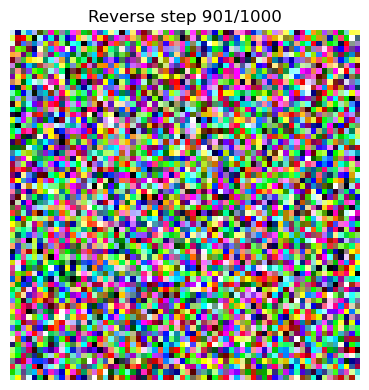

This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is th

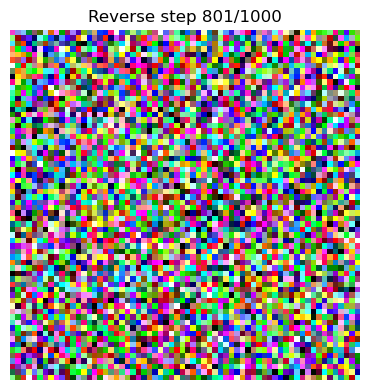

This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is th

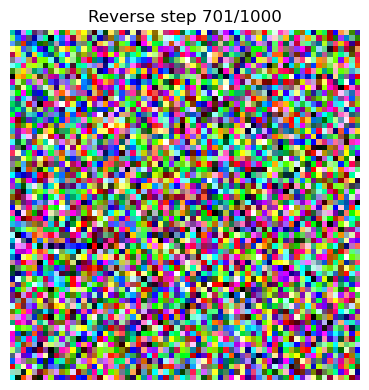

This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is th

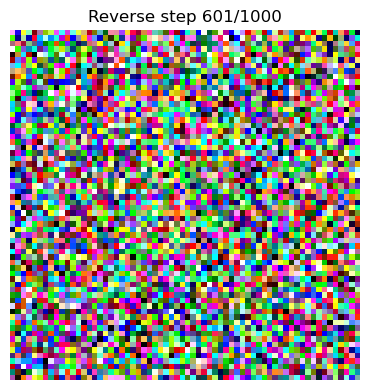

This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is th

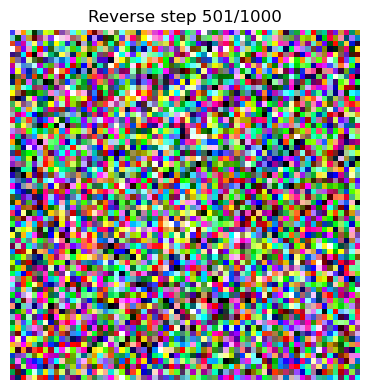

This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is th

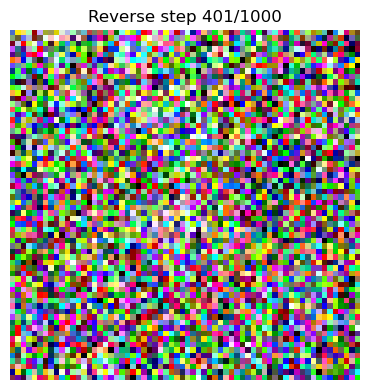

This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is th

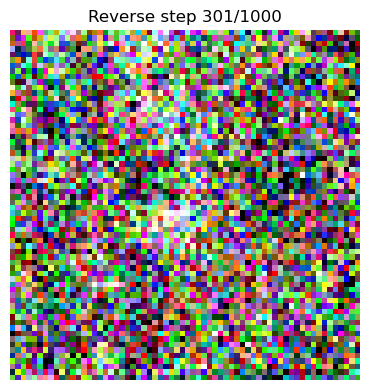

This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is th

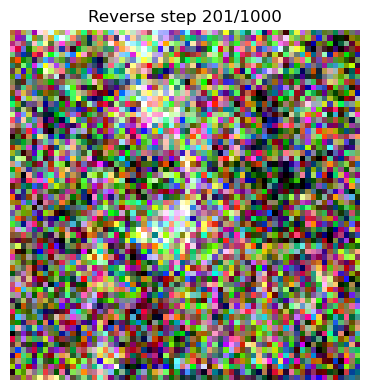

This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is th

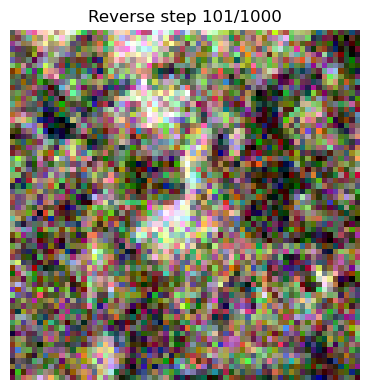

This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is the current dt: 0.001
This is th

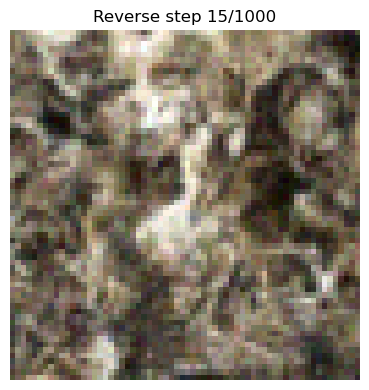

This is the current dt: 0.001
Statistics for each timestep:
Drift: mean drift -6.497083813883364e-05, std drift: 0.005510400515049696
Diffusion: mean diff 0.01893937774002552, std diff: nan
Update: mean difference (x_new - x_prev): mean_difference = 2.0791232600458898e-05, std_difference = 0.01974881999194622
[reverse step 14/1000 | i=13 | t=0.0130]
global: mean=-0.1603, std=0.3780, min=-1.0288, max=1.1040
  ch 0: mean=-0.0623, std=0.3779, min≈-0.8984, max≈1.0928
  ch 1: mean=-0.1435, std=0.3722, min≈-1.0036, max≈1.1040
  ch 2: mean=-0.2752, std=0.3525, min≈-1.0288, max≈1.0669
Time of last 100 steps: 0.362. Time remaining (rough heuristic): 36.218.



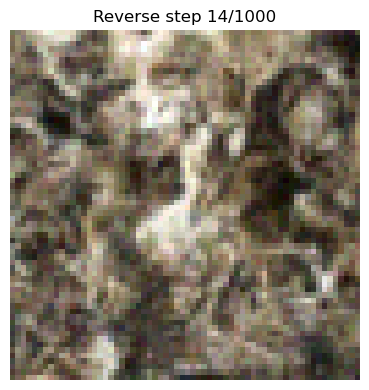

This is the current dt: 0.001
Statistics for each timestep:
Drift: mean drift -6.944372580619529e-05, std drift: 0.005502673331648111
Diffusion: mean diff 0.018406521528959274, std diff: nan
Update: mean difference (x_new - x_prev): mean_difference = 0.00020866708655375987, std_difference = 0.01936633512377739
[reverse step 13/1000 | i=12 | t=0.0120]
global: mean=-0.1601, std=0.3776, min=-1.0179, max=1.1129
  ch 0: mean=-0.0623, std=0.3775, min≈-0.8835, max≈1.1129
  ch 1: mean=-0.1431, std=0.3717, min≈-0.9836, max≈1.0951
  ch 2: mean=-0.2749, std=0.3523, min≈-1.0179, max≈1.0386
Time of last 100 steps: 0.360. Time remaining (rough heuristic): 36.045.



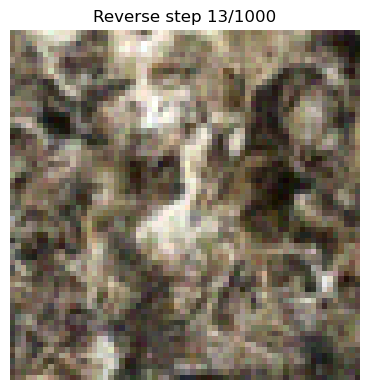

This is the current dt: 0.001
Statistics for each timestep:
Drift: mean drift -7.470323907909915e-05, std drift: 0.005501975771039724
Diffusion: mean diff 0.01785777136683464, std diff: nan
Update: mean difference (x_new - x_prev): mean_difference = -0.00012148559471825138, std_difference = 0.018429158255457878
[reverse step 12/1000 | i=11 | t=0.0110]
global: mean=-0.1602, std=0.3771, min=-1.0227, max=1.1194
  ch 0: mean=-0.0627, std=0.3771, min≈-0.8984, max≈1.0702
  ch 1: mean=-0.1432, std=0.3713, min≈-0.9769, max≈1.1194
  ch 2: mean=-0.2748, std=0.3516, min≈-1.0227, max≈1.0269
Time of last 100 steps: 0.359. Time remaining (rough heuristic): 35.877.



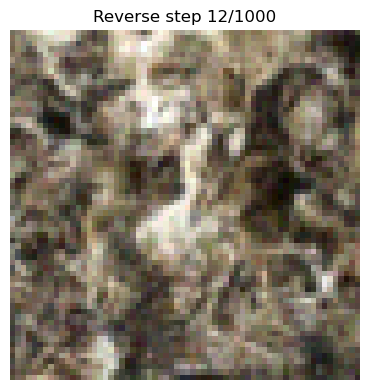

This is the current dt: 0.001
Statistics for each timestep:
Drift: mean drift -8.048247400438413e-05, std drift: 0.005489987321197987
Diffusion: mean diff 0.017291616648435593, std diff: nan
Update: mean difference (x_new - x_prev): mean_difference = 0.0001242551952600479, std_difference = 0.01801941730082035
[reverse step 11/1000 | i=10 | t=0.0100]
global: mean=-0.1601, std=0.3767, min=-1.0236, max=1.1608
  ch 0: mean=-0.0630, std=0.3767, min≈-0.8921, max≈1.0914
  ch 1: mean=-0.1430, std=0.3711, min≈-0.9400, max≈1.1608
  ch 2: mean=-0.2744, std=0.3512, min≈-1.0236, max≈1.0242
Time of last 100 steps: 0.369. Time remaining (rough heuristic): 36.930.



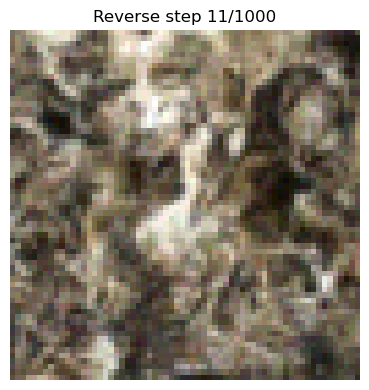

This is the current dt: 0.001
Statistics for each timestep:
Drift: mean drift -8.668399095768109e-05, std drift: 0.005500279366970062
Diffusion: mean diff 0.01670628786087036, std diff: nan
Update: mean difference (x_new - x_prev): mean_difference = 0.0001008769977488555, std_difference = 0.017630282789468765
[reverse step 10/1000 | i=9 | t=0.0090]
global: mean=-0.1600, std=0.3763, min=-0.9958, max=1.1393
  ch 0: mean=-0.0631, std=0.3762, min≈-0.8974, max≈1.0821
  ch 1: mean=-0.1426, std=0.3708, min≈-0.9546, max≈1.1393
  ch 2: mean=-0.2743, std=0.3508, min≈-0.9958, max≈1.0318
Time of last 100 steps: 0.375. Time remaining (rough heuristic): 37.452.



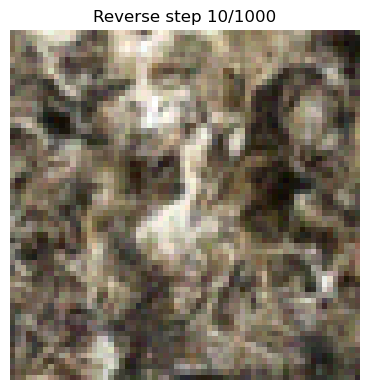

This is the current dt: 0.001
Statistics for each timestep:
Drift: mean drift -9.447347110835835e-05, std drift: 0.005527560133486986
Diffusion: mean diff 0.01609969139099121, std diff: nan
Update: mean difference (x_new - x_prev): mean_difference = -8.34543152450351e-06, std_difference = 0.017137911170721054
[reverse step 9/1000 | i=8 | t=0.0080]
global: mean=-0.1600, std=0.3760, min=-1.0017, max=1.1495
  ch 0: mean=-0.0630, std=0.3759, min≈-0.8899, max≈1.0843
  ch 1: mean=-0.1428, std=0.3709, min≈-0.9370, max≈1.1495
  ch 2: mean=-0.2742, std=0.3502, min≈-1.0017, max≈1.0304
Time of last 100 steps: 0.347. Time remaining (rough heuristic): 34.697.



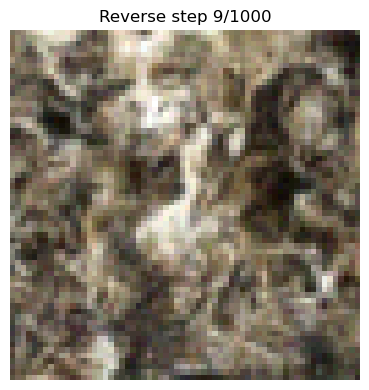

This is the current dt: 0.001
Statistics for each timestep:
Drift: mean drift -0.00010214784560957924, std drift: 0.005560499615967274
Diffusion: mean diff 0.015469325706362724, std diff: nan
Update: mean difference (x_new - x_prev): mean_difference = -3.040742922166828e-05, std_difference = 0.016574975103139877
[reverse step 8/1000 | i=7 | t=0.0070]
global: mean=-0.1601, std=0.3757, min=-0.9975, max=1.1360
  ch 0: mean=-0.0632, std=0.3756, min≈-0.8927, max≈1.0925
  ch 1: mean=-0.1428, std=0.3708, min≈-0.9403, max≈1.1360
  ch 2: mean=-0.2742, std=0.3496, min≈-0.9975, max≈1.0561
Time of last 100 steps: 0.365. Time remaining (rough heuristic): 36.499.



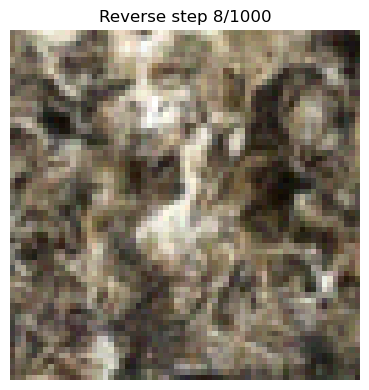

This is the current dt: 0.001
Statistics for each timestep:
Drift: mean drift -0.00011163706221850589, std drift: 0.005628162994980812
Diffusion: mean diff 0.014812158420681953, std diff: nan
Update: mean difference (x_new - x_prev): mean_difference = 0.00014083650603424758, std_difference = 0.015603202395141125
[reverse step 7/1000 | i=6 | t=0.0060]
global: mean=-0.1599, std=0.3754, min=-1.0032, max=1.1238
  ch 0: mean=-0.0633, std=0.3751, min≈-0.9061, max≈1.1148
  ch 1: mean=-0.1423, std=0.3708, min≈-0.9167, max≈1.1238
  ch 2: mean=-0.2741, std=0.3493, min≈-1.0032, max≈1.0743
Time of last 100 steps: 0.362. Time remaining (rough heuristic): 36.168.



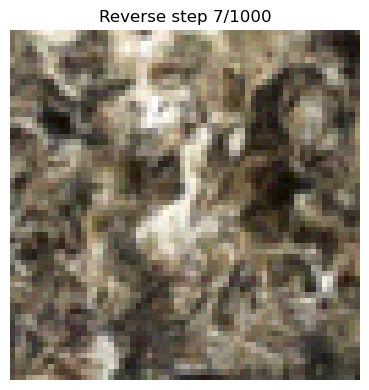

This is the current dt: 0.001
Statistics for each timestep:
Drift: mean drift -0.00012307938595768064, std drift: 0.005756462924182415
Diffusion: mean diff 0.014124447479844093, std diff: nan
Update: mean difference (x_new - x_prev): mean_difference = 0.00013517802290152758, std_difference = 0.015407651662826538
[reverse step 6/1000 | i=5 | t=0.0050]
global: mean=-0.1598, std=0.3750, min=-0.9909, max=1.1289
  ch 0: mean=-0.0631, std=0.3746, min≈-0.9171, max≈1.1289
  ch 1: mean=-0.1423, std=0.3704, min≈-0.9251, max≈1.1191
  ch 2: mean=-0.2739, std=0.3490, min≈-0.9909, max≈1.0502
Time of last 100 steps: 0.366. Time remaining (rough heuristic): 36.599.



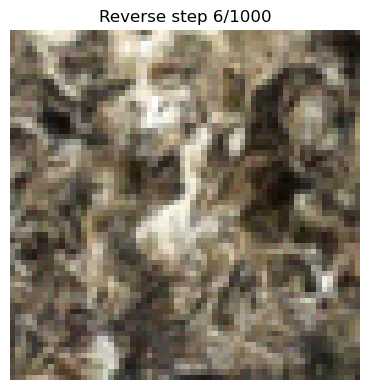

This is the current dt: 0.001
Statistics for each timestep:
Drift: mean drift -0.0001387938391417265, std drift: 0.00597974332049489
Diffusion: mean diff 0.013401494361460209, std diff: nan
Update: mean difference (x_new - x_prev): mean_difference = 0.00021324022964108735, std_difference = 0.01459734421223402
[reverse step 5/1000 | i=4 | t=0.0040]
global: mean=-0.1596, std=0.3751, min=-0.9931, max=1.1461
  ch 0: mean=-0.0628, std=0.3749, min≈-0.8976, max≈1.1461
  ch 1: mean=-0.1423, std=0.3702, min≈-0.9338, max≈1.1239
  ch 2: mean=-0.2737, std=0.3490, min≈-0.9931, max≈1.0634
Time of last 100 steps: 0.352. Time remaining (rough heuristic): 35.198.



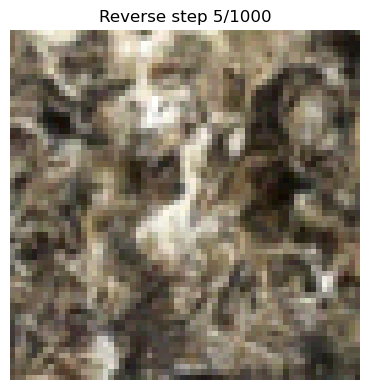

This is the current dt: 0.001
Statistics for each timestep:
Drift: mean drift -0.00016117143968585879, std drift: 0.006303905043751001
Diffusion: mean diff 0.012637247331440449, std diff: nan
Update: mean difference (x_new - x_prev): mean_difference = 5.389974103309214e-05, std_difference = 0.014050314202904701
[reverse step 4/1000 | i=3 | t=0.0030]
global: mean=-0.1595, std=0.3748, min=-0.9911, max=1.1435
  ch 0: mean=-0.0628, std=0.3746, min≈-0.9156, max≈1.1435
  ch 1: mean=-0.1422, std=0.3698, min≈-0.9234, max≈1.1277
  ch 2: mean=-0.2736, std=0.3489, min≈-0.9911, max≈1.0742
Time of last 100 steps: 0.344. Time remaining (rough heuristic): 34.418.



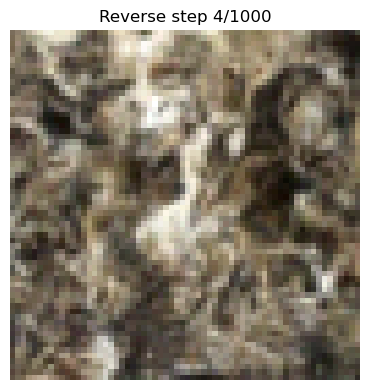

In [9]:
# 3. Run Sampling (Fixes the AttributeError via the class update)
samples = diffusion.reverse_process(
    model=model_fn,              # Pass the wrapper!
    shape=(batch_size, 3, image_size, image_size),
    num_steps=cfg.get('N', 10),
    probability_flow=False,
    device=device                # Pass device explicitly
)

Sample stats: Min=-0.99, Max=1.14, Mean=-0.16


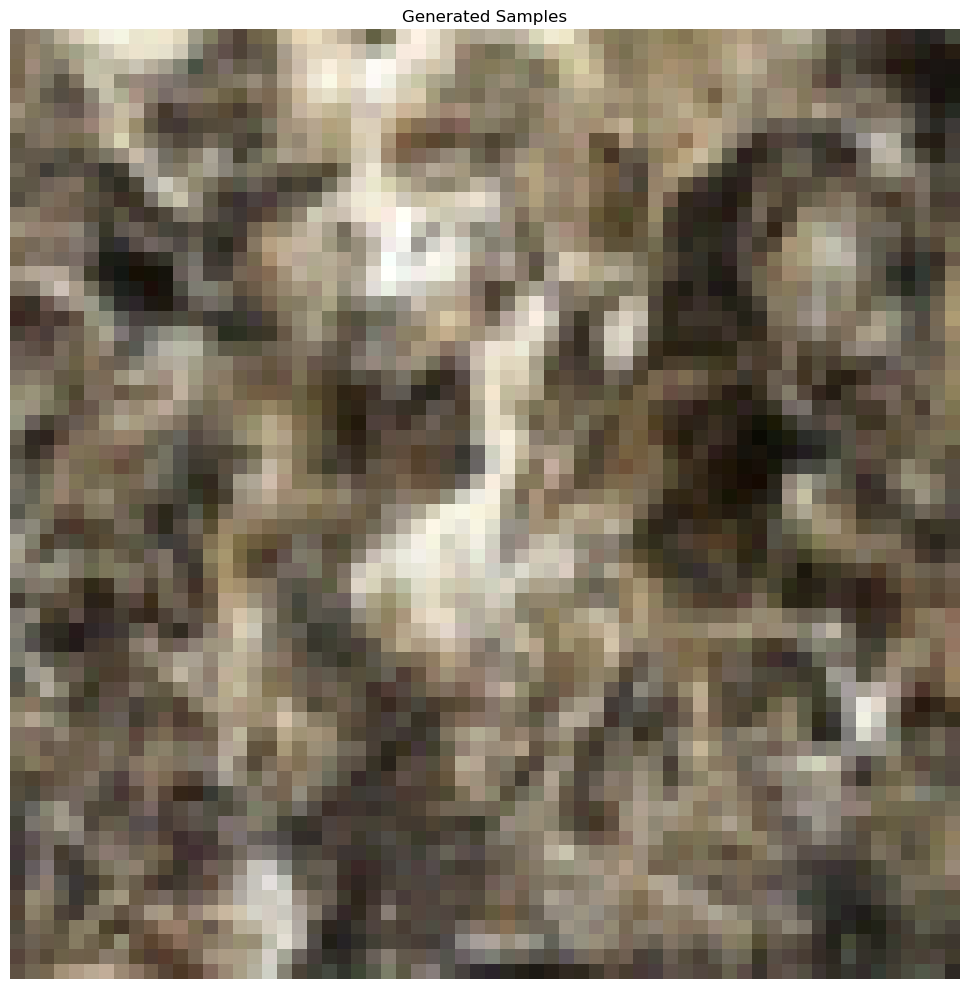

In [10]:
def show_samples(samples):
    # 1. Ensure we are on CPU
    samples_vis = samples.detach().cpu()
    
    # 2. Inspect statistics (Crucial for debugging!)
    print(f"Sample stats: Min={samples_vis.min():.2f}, Max={samples_vis.max():.2f}, Mean={samples_vis.mean():.2f}")
    
    # 3. Robust Normalization
    # SDE models often output values outside [-1, 1] before the final step.
    # If strict [-1, 1] is expected:
    samples_vis = samples_vis.clamp(-1.0, 1.0)
    samples_vis = (samples_vis + 1.0) / 2.0
    
    # 4. Create Grid
    # nrow=int(np.sqrt(batch_size)) automatically makes a square grid
    grid = torchvision.utils.make_grid(samples_vis, nrow=int(np.sqrt(samples_vis.shape[0])), padding=2)
    
    # 5. Permute for Matplotlib
    np_grid = grid.permute(1, 2, 0).numpy()
    
    # 6. Plot
    plt.figure(figsize=(10, 10))
    plt.imshow(np_grid)
    plt.axis("off")
    plt.title("Generated Samples")
    plt.tight_layout()
    plt.show()

# Run the visualization
show_samples(samples)

In [11]:
# import torch
# import functools
# from models import utils as mutils  # Helper from score_sde to handle device mapping
# from models.ncsnpp import NCSNpp  # You must have the 'models' folder from score_sde

In [12]:
# # ==========================================
# # 1. Recreate the Config (Exact parameters for CelebA-HQ 256 VE)
# # ==========================================
# # We use a dummy class to mimic the ML_Collections config object used in the original repo
# class Config:
#     def __init__(self):
#         self.data = type('data', (), {})()
#         self.model = type('model', (), {})()

#     def __repr__(self):
#         return "Config()"

# def get_celebahq_config():
#     config = Config()
    
#     # Data settings
#     config.data.image_size = 256
#     config.data.channels = 3
#     config.data.centered = False
    
#     # Model architecture settings (NCSN++)
#     config.model.name = 'ncsnpp'
#     config.model.sigma_max = 378.0  # Specific to VE/CelebA
#     config.model.sigma_min = 0.01
#     config.model.num_scales = 2000  # Used for embedding size
#     config.model.scale_by_sigma = True # IMPORTANT: Confirms it predicts SCALED score
#     config.model.ema_rate = 0.999
    
#     config.model.nf = 128           # Number of filters (base channels)
#     config.model.ch_mult = (1, 1, 2, 2, 2, 2, 2) # Channel multipliers per level
#     config.model.num_res_blocks = 2
#     config.model.attn_resolutions = (16,)
#     config.model.resamp_with_conv = True
#     config.model.conditional = True
#     config.model.fir = True         # Finite Impulse Response (Anti-aliasing)
#     config.model.fir_kernel = [1, 3, 3, 1]
#     config.model.skip_rescale = True
#     config.model.resblock_type = 'biggan'
#     config.model.progressive = 'none'
#     config.model.progressive_input = 'residual'
#     config.model.progressive_combine = 'sum'
#     config.model.embedding_type = 'fourier'
#     config.model.fourier_scale = 16.0
#     config.model.init_scale = 0.0
#     config.model.dropout = 0.0
#     config.model.conv_size = 3
    
#     return config

# # ==========================================
# # 2. The Loading Function
# # ==========================================
# def load_original_checkpoint(checkpoint_path, device='cuda'):
#     # A. Init the Configuration
#     config = get_celebahq_config()
    
#     # B. Instantiate the Model
#     # The original NCSNpp takes the config as the primary argument
#     model = NCSNpp(config)
#     model = model.to(device)
    
#     # C. Load the Weights
#     # map_location ensures we load correctly even if saved on different GPU
#     loaded_state = torch.load(checkpoint_path, map_location=device)
    
#     # Song's checkpoints usually save the EMA weights directly or in 'model' key
#     # We try to find the state_dict
#     if 'model' in loaded_state:
#         state_dict = loaded_state['model']
#     elif 'ema' in loaded_state:
#         # Often the EMA weights are preferred for generation quality
#         print("Loading EMA weights (better quality)...")
#         state_dict = loaded_state['ema']
#     else:
#         state_dict = loaded_state

#     # D. Strict Loading
#     # We use strict=False initially to debug, but ideally it should be True
#     missing, unexpected = model.load_state_dict(state_dict, strict=False)
    
#     if len(missing) > 0:
#         print(f"WARNING: Missing keys: {missing[:5]}...")
#     if len(unexpected) > 0:
#         print(f"WARNING: Unexpected keys: {unexpected[:5]}...")
        
#     model.eval()
#     return model

# # Usage
# # model = load_original_checkpoint("ve/celebahq_256_ncsnpp_continuous.pth")